# Lab: Regression Tree

*In this lab, we will build a **Regression Tree** model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

> ### 📝 1. Business Understanding Report (Summary)
>
> - **Business Context:** This project addresses a real-estate analytics scenario for a hypothetical company, **"Housewise Analytics"**, operating in the California housing market. California's housing market is characterized by diverse neighborhoods, rapidly changing prices, and growing demand for data-driven decision-making among buyers, sellers, and realtors.
> - **Business Problem:** Stakeholders currently rely on broad averages or intuition, lacking a precise and explainable method to estimate home prices for specific neighborhoods and property characteristics. This uncertainty leads to lost sales opportunities, mispricing, and inefficient market decisions.
> - **Project Goal:** To build a **predictive model** that uses available district-level features (such as location, median income, number of rooms, and more) to accurately estimate median home values in California. The objective is to empower more confident and data-driven pricing decisions that benefit both buyers and sellers.

---

> ### 📝 2. Analytic Approach Report (Summary)
>
> - **Problem Type:** *Supervised Regression* - the goal is to predict a **continuous numerical value** (median house value) from district-level features.
> - **Model Selection:** For this lab, the baseline (and the only candidate) model is a **Regression Tree (Decision Tree Regressor)**. This approach was chosen because it can naturally handle non-linear relationships and feature interactions, which are common in housing data. (Note: In previous labs, simple and multiple linear regression were already explored.)
> - **Evaluation Metrics:**
>   - **R-squared (R²) and Adjusted R-squared:** To measure how much of the variance in house values the model can explain, while adjusting for the number of features.
>   - **RMSE (Root Mean Squared Error):** To provide a direct and interpretable measure of average prediction errors, using the original units of the target (house value in $100,000s).
>   - **Feature Importance:** To identify which features (e.g., median income, rooms, latitude/longitude) have the largest impact on price predictions.
> - **Motivation for Model Selection:** In a real-world analytic workflow, **Exploratory Data Analysis (EDA)** would precede model building. EDA (including scatterplots and residual analysis) often uncovers non-linear relationships between predictors and housing prices, motivating the use of regression trees. Regression trees can capture threshold, interaction, and piecewise patterns that linear models miss.
>
> ⚠️ **Caution:** For clarity and focus, this lab considers only a regression tree. In real-world projects, it is best practice to compare several modeling approaches (including advanced ensembles and regularized models) to select the most robust solution.

---

> ### 📝 3. Data Requirements Report (Summary)
>
> - **Data Source:** The lab will use the **California Housing dataset** (available via scikit-learn), which includes data aggregated from 20,000+ block groups across California.
> - **Features (Independent Variables):**
>    - **MedInc**: Median income in block group (`med_income`)
>    - **HouseAge**: median house age in block group (`med_age`)
>    - **AveRooms**: average number of rooms per household (`avg_rooms`)
>    - **AveBedrms**: average number of bedrooms per household (`avg_bedrooms`)
>    - **Population**: block group population (`population`)
>    - **AveOccup**: average number of household members (`avg_occup`)
>    - **Latitude**: block group latitude (`lat`)
>    - **Longitude**: block group longitude (`long`)
> - **Target (Dependent Variable):** Median house value for California districts, expressed in hundreds of thousands of dollars ($100,000s). (`med_value`)
> - **Granularity & Privacy:** Each row represents aggregated statistics for a California census block group (district), not individual households. The dataset is fully anonymized and contains no sensitive or personally identifiable information (PII).

---

## Stage 4: Data Collection

In [28]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

### 4.1 Extraction

In [29]:
# Extract data from the source system
try:
    raw_data = fetch_california_housing()
    print(f"Data has been extracted from the source system as '{type(raw_data)}'")
except Exception as e:
    print(f"An error occurred while extracting data: {e}")

Data has been extracted from the source system as '<class 'sklearn.utils._bunch.Bunch'>'


In [30]:
# Create a DataFrame with the original, untouched column names
raw_df = pd.DataFrame(data=raw_data.data, columns=raw_data.feature_names)
raw_df['target'] = raw_data.target

# Define and create the raw data directory
raw_data_dir = Path("../data/raw")
raw_data_dir.mkdir(parents=True, exist_ok=True)

# Define the file path and save the raw DataFrame
raw_data_path = raw_data_dir / "california_housing_raw_v1.csv"
raw_df.to_csv(raw_data_path, index=False)

print(f"Extracted data has {raw_df.shape[0]} samples and {raw_df.shape[1]} features, with {raw_df.isnull().values.sum()} missing values out of {raw_df.size}.")
print(f"Raw, untouched data has been saved to: {raw_data_path}\n")
raw_df.head()

Extracted data has 20640 samples and 9 features, with 0 missing values out of 185760.
Raw, untouched data has been saved to: ../data/raw/california_housing_raw_v1.csv



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 4.2. Transformation

In [31]:
# Read the raw data
interim_df = pd.read_csv(raw_data_path)

In [32]:
# Rename columns
interim_df = interim_df.rename(columns={
    'MedInc':'med_income',
    'HouseAge': 'med_age',
    'AveRooms': 'avg_rooms',
    'AveBedrms': 'avg_bedrooms',
    'Population': 'population',
    'AveOccup': 'avg_occup',
    'Latitude': 'lat',
    'Longitude': 'long',
    'target': 'med_value'
})

In [33]:
# Manually check the minimum and maximum values for all numerical columns for any abnormalities
print("\n--- Min/Max Summary of Numerical Data ---")
display(interim_df.describe().loc[['min', 'max']]) 


--- Min/Max Summary of Numerical Data ---


,med_income,med_age,avg_rooms,avg_bedrooms,population,avg_occup,lat,long,med_value
min,0.4999,1.0,0.846154,0.333333,3.0,0.692308,32.54,-124.35,0.14999
max,15.0001,52.0,141.909091,34.066667,35682.0,1243.333333,41.95,-114.31,5.00001


* 📌 There seems to be unusually high values in average rooms, average bedrooms, population, and average occupancy. However, at this stage we can not be 100% sure that these are data entry errors, as they may represent legitimate cases such as hotels, group living environments, or unique properties.

### 4.3. Loading

In [34]:
# Define and create the interim data directory
interim_data_dir = Path("../data/interim")
interim_data_dir.mkdir(parents=True, exist_ok=True)

# Define the interim file path and save the transformed DataFrame
interim_data_path = interim_data_dir / "california_housing_interim_v1.parquet"
interim_df.to_parquet(interim_data_path, index=False)

### 4.4. Verification

In [35]:
# Load the final interim data and verify its contents
try:
    df_verified = pd.read_parquet(interim_data_path)
    print(f"Verification successful. The following DataFrame is ready for analysis with {df_verified.shape[0]} samples and {df_verified.shape[1]} features:")
    display(df_verified.sample(5))
except Exception as e:
    print(f"An error occurred while verifying the interim data: {e}")

Verification successful. The following DataFrame is ready for analysis with 20640 samples and 9 features:


,med_income,med_age,avg_rooms,avg_bedrooms,population,avg_occup,lat,long,med_value
6510,3.2373,32.0,4.340097,1.038647,4119.0,3.979710,34.07,-118.05,1.831
19894,1.3444,32.0,3.528646,0.945312,1427.0,3.716146,36.30,-119.20,0.456
1082,0.9870,52.0,4.328283,1.171717,520.0,2.626263,39.73,-121.84,1.125
13035,2.5183,15.0,5.487544,0.991103,1040.0,1.850534,38.71,-121.17,2.933
8487,2.6182,34.0,3.234000,0.986000,1530.0,3.060000,33.91,-118.30,1.726



---

> ### 📝 4. Data Collection Report (Summary)
> 
> - **Extraction:** The California Housing dataset was retrieved from scikit-learn's repository and saved in its original, untouched form as a raw `.csv` file for reproducibility and provenance.
> - **Transformation:**
>   - All columns were renamed as specified in the Data Requirements Report (Summary).
>   - Data quality checks revealed unusually high values in average rooms (`avg_rooms`), average bedrooms (`avg_bedrooms`), population (`population`), and average occupancy (`avg_occup`). These potential outliers were **not** automatically removed during transformation, as they may represent legitimate cases such as hotels, group living environments, or unique properties. Determining their treatment is left for the data scientist at the EDA stage, based on domain knowledge and analytic objectives.
> - **Loading:** The standardized dataset was saved as a `.parquet` file in the `/data/interim` directory, providing an analysis-ready starting point for all subsequent work.
> - **Verification:** The interim DataFrame contains 20,640 rows and 9 columns, with all variable names in snake_case and no missing values detected.

---

## Stage 5: Data Understanding

### 5.1. Preparation for Exploratory Data Analysis (EDA)

In [36]:
# Create a new DataFrame for the EDA, with the useful columns
df_eda = df_verified.copy() # We need ALL columns

# Final check for the column names, data types, null values, and memory usage
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   med_income    20640 non-null  float64
 1   med_age       20640 non-null  float64
 2   avg_rooms     20640 non-null  float64
 3   avg_bedrooms  20640 non-null  float64
 4   population    20640 non-null  float64
 5   avg_occup     20640 non-null  float64
 6   lat           20640 non-null  float64
 7   long          20640 non-null  float64
 8   med_value     20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [37]:
# Sample 5 rows from the DataFrame to verify that the DataFrame is ready for EDA
df_eda.sample(5)

,med_income,med_age,avg_rooms,avg_bedrooms,population,avg_occup,lat,long,med_value
11805,2.8194,9.0,5.039966,1.079082,3369.0,2.864796,38.89,-121.32,1.113
14575,3.5078,24.0,3.596059,0.965517,335.0,1.650246,32.81,-117.22,3.625
5021,2.8542,44.0,5.269231,1.063187,1041.0,2.859890,33.99,-118.33,1.265
10413,4.6076,6.0,4.665773,1.087578,2597.0,2.320822,33.66,-117.64,2.040
15221,4.3548,17.0,5.713942,1.054087,2412.0,2.899038,32.97,-117.06,1.923


In [38]:
# Create useful data structures for EDA
numeric_cols = df_eda.columns.to_list()
numeric_features = numeric_cols[:-1]
cols_dict = {
    'med_income': 'Median Income',
    'med_age': 'Median House Age',
    'avg_rooms': 'Average Number of Rooms per Household',
    'avg_bedrooms': 'Average Number of Bedrooms per Household',
    'population': 'Population',
    'avg_occup': 'Average Number of Household Members',
    'lat': 'Latitude',
    'long': 'Longitude',
    'med_value': 'Median House Value (in $100,000s)'
}

### 5.2. Descriptive Statistics

In [39]:
# Generate the descriptive statistics for the numerical variables
stats_df = df_eda.describe().T

# Calculate and add the Coefficient of Variation (CV) column
stats_df['cv'] = stats_df['std'] / stats_df['mean']

# Display the result
stats_df

,count,mean,std,min,25%,50%,75%,max,cv
med_income,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100,0.490825
med_age,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000,0.439448
avg_rooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091,0.455733
avg_bedrooms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667,0.432134
population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000,0.794444
avg_occup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333,3.382356
lat,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000,0.059945
long,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000,-0.016756
med_value,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010,0.557855


* 📌 **`med_income`** has a wide spread (CV ≈ 0.49) with values ranging from ~$0.5$k to $15$k, indicating significant economic diversity among California districts. This variable is likely to be an important predictor for housing value splits.
* 📌 **`population`** shows high variability (CV ≈ 0.79) and extreme maximum values (over 35,000), which may signal the presence of large or aggregated block groups—regression trees can naturally handle such heterogeneity without requiring transformation.
* 📌 **`avg_rooms`** and **avg_bedrooms** both have moderate variability (CV ≈ 0.46 and 0.43) but their maximum values (142 and 34, respectively) are much higher than the 75th percentile, suggesting clusters of very large buildings (e.g., apartments, hotels)—tree-based splits are well-suited to capture such discontinuities.
* 📌 **`avg_occup`** (average occupancy) is extremely skewed (CV ≈ 3.38, max ≈ 1243), reflecting that a small number of districts have dramatically higher values; such outliers won’t destabilize regression trees, making this model robust to including the full data range.
* 📌 **`med_value`** (target) also displays high dispersion (CV ≈ 0.56), supporting the value of flexible, non-linear approaches like regression trees to model price variability.
* 📌 Both **`lat`** and **`long`** have low CV and broad ranges, confirming the data captures geographic diversity across California, which regression trees can exploit when identifying location-based value thresholds.

### 5.3. Univariate Analysis
To understand the distribution and variability of each variable, we plot histograms and boxplots. This helps spot skewness, outliers, modality, and informs transformations or splitting for regression trees. The target variable `med_value` is given particular attention.

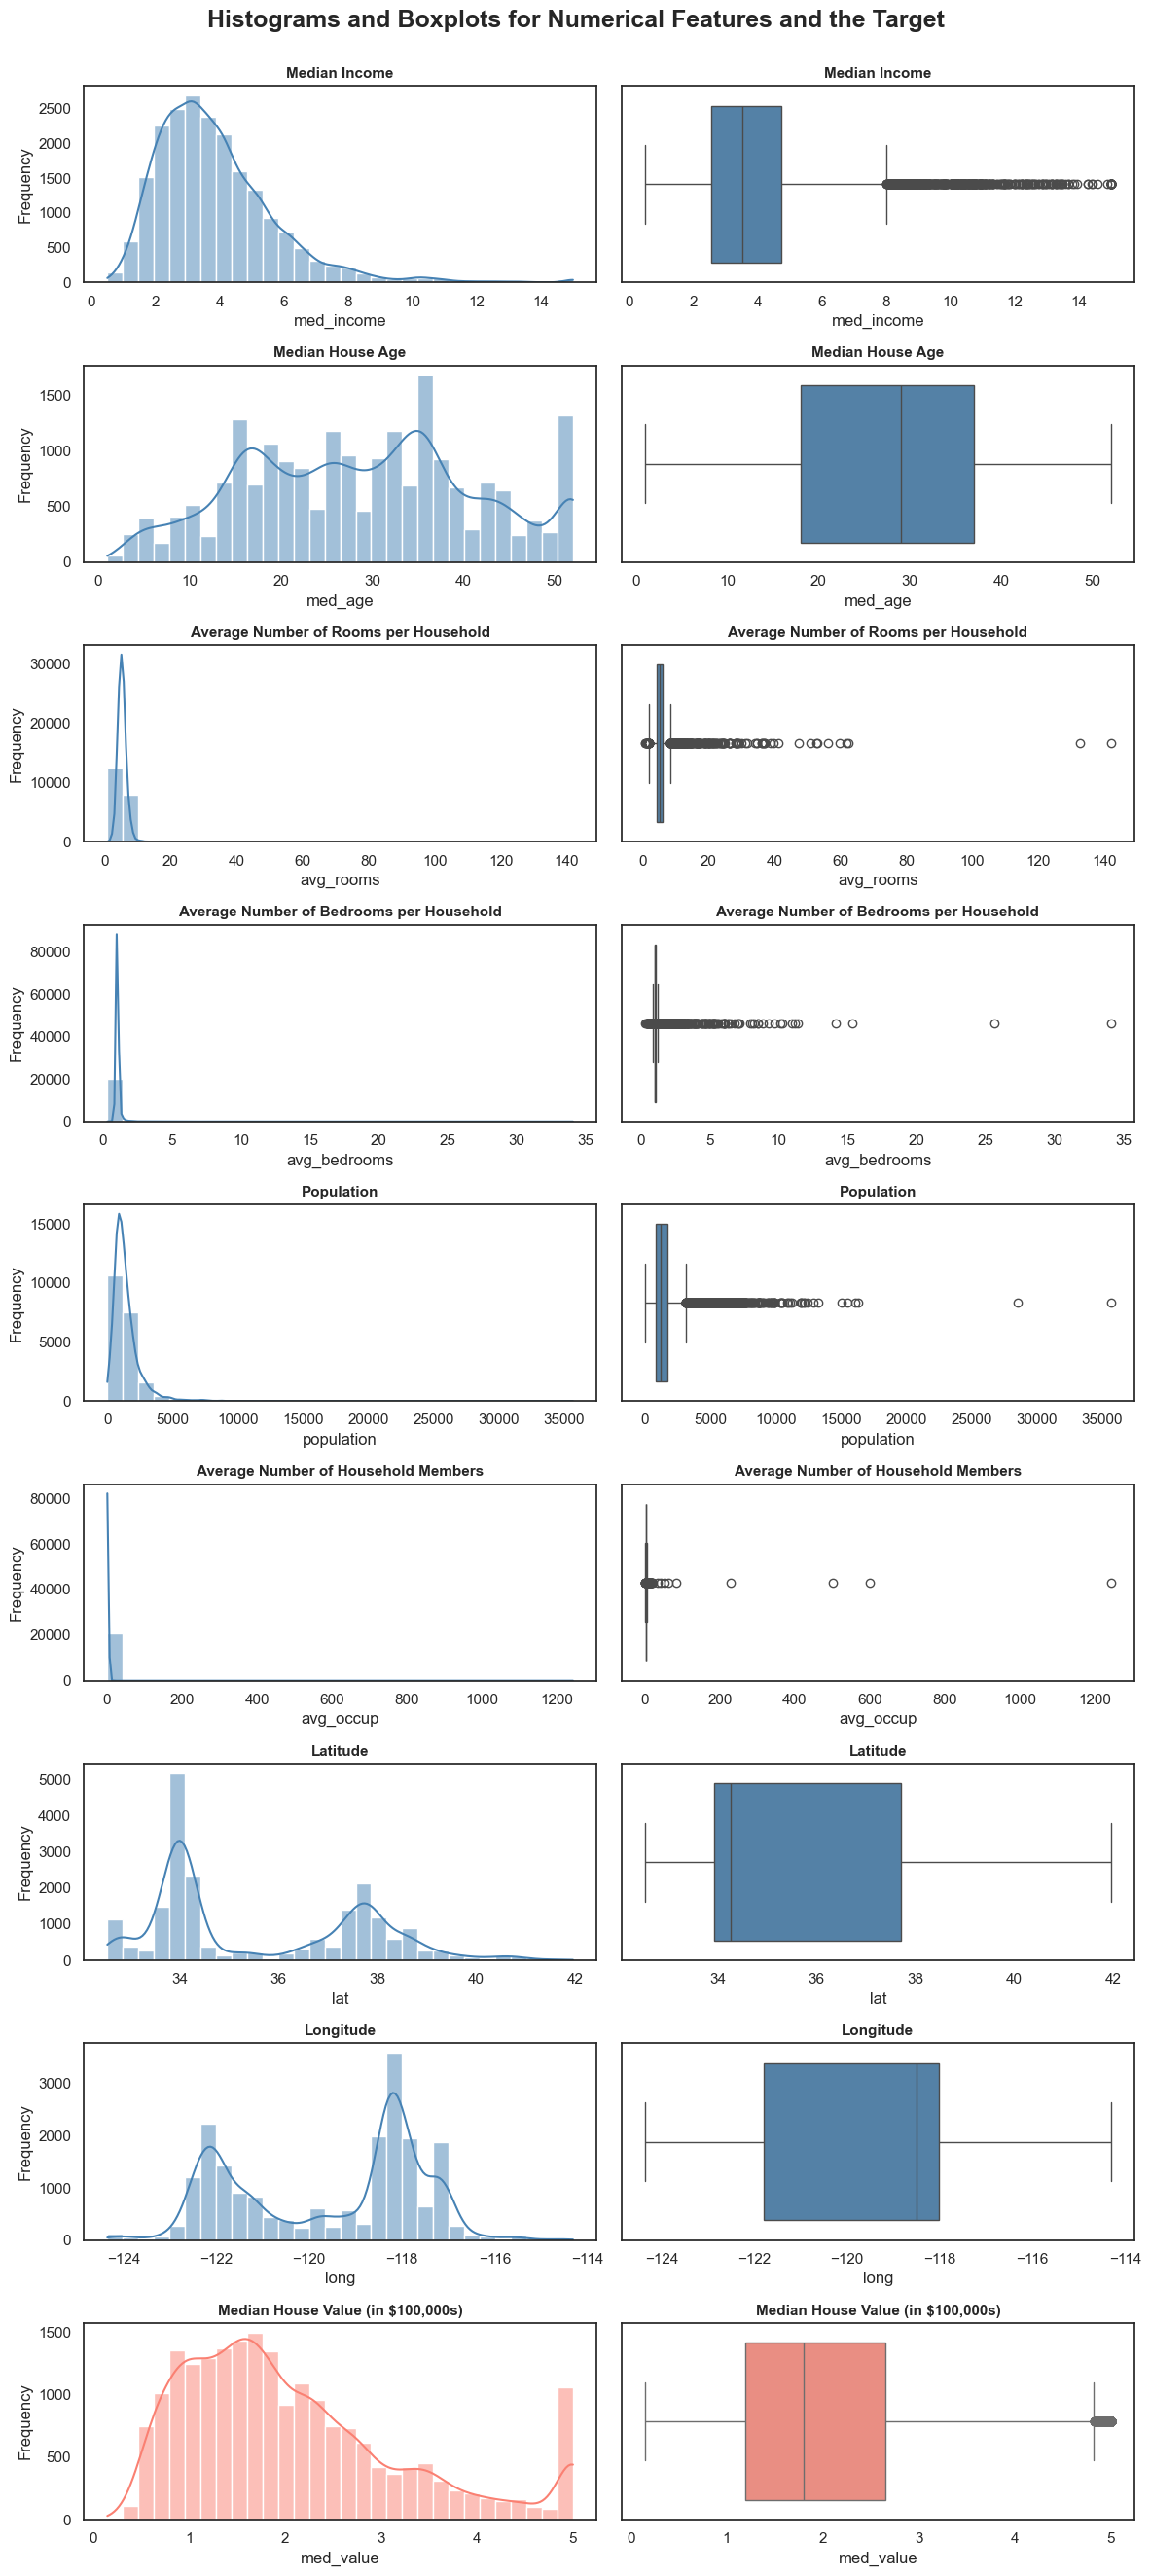

In [40]:
n = len(numeric_cols)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, n * 3))

for i, col in enumerate(numeric_cols):
    color = "salmon" if col == "med_value" else "steelblue"
    
    # Histograms (left column)
    sns.histplot(data=df_eda, x=col, kde=True, bins=30, ax=axes[i, 0], color=color)
    axes[i, 0].set_title(cols_dict[col], fontsize=11, fontweight="bold")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Frequency")
    
    # Boxplots (right column)
    sns.boxplot(data=df_eda, x=col, ax=axes[i, 1], orient="h", color=color)
    axes[i, 1].set_title(cols_dict[col], fontsize=11, fontweight="bold")
    axes[i, 1].set_xlabel(col)

plt.suptitle("Histograms and Boxplots for Numerical Features and the Target", fontsize=18, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

* 📌 The histogram and boxplot visualizations reveal pronounced right-skew in several key features (`med_income`, `avg_rooms`, `avg_bedrooms`, `population`, `avg_occup`), with most values clustered at the lower end and a long tail of higher values. The target variable (`med_value`) also exhibits right-skew, with a notable spike at the maximum value, possibly resulting from upper-capping in the original dataset and/or representing a limit of recordable home prices.
* 📌 Outliers are present in features such as `avg_rooms`, `avg_bedrooms`, `population`, and especially `avg_occup` (where some values are orders of magnitude higher than the median), reflecting either true aggregations (such as group dwellings, hotels, or populous regions) or encoding/reporting phenomena. Importantly, **regression trees are robust to extreme values and do not require outlier removal or feature transformation to maintain predictive performance.**
* 📌 The presence of skew, heavy tails, and outliers in multiple features justifies the choice of a regression tree for modeling, as tree-based methods can partition the data adaptively and are not sensitive to non-normality or extreme values in predictors or the target.

### 5.4. Bivariate Analysis
To understand which features might be most useful for tree-based splits, we visualize bivariate relationships between each predictor and the target (`med_value`). Unlike linear models, regression trees are effective at capturing abrupt changes, thresholds, and interactions in the data rather than just gradual trends. We focus on identifying predictors with pronounced non-linear patterns or step changes associated with housing values.

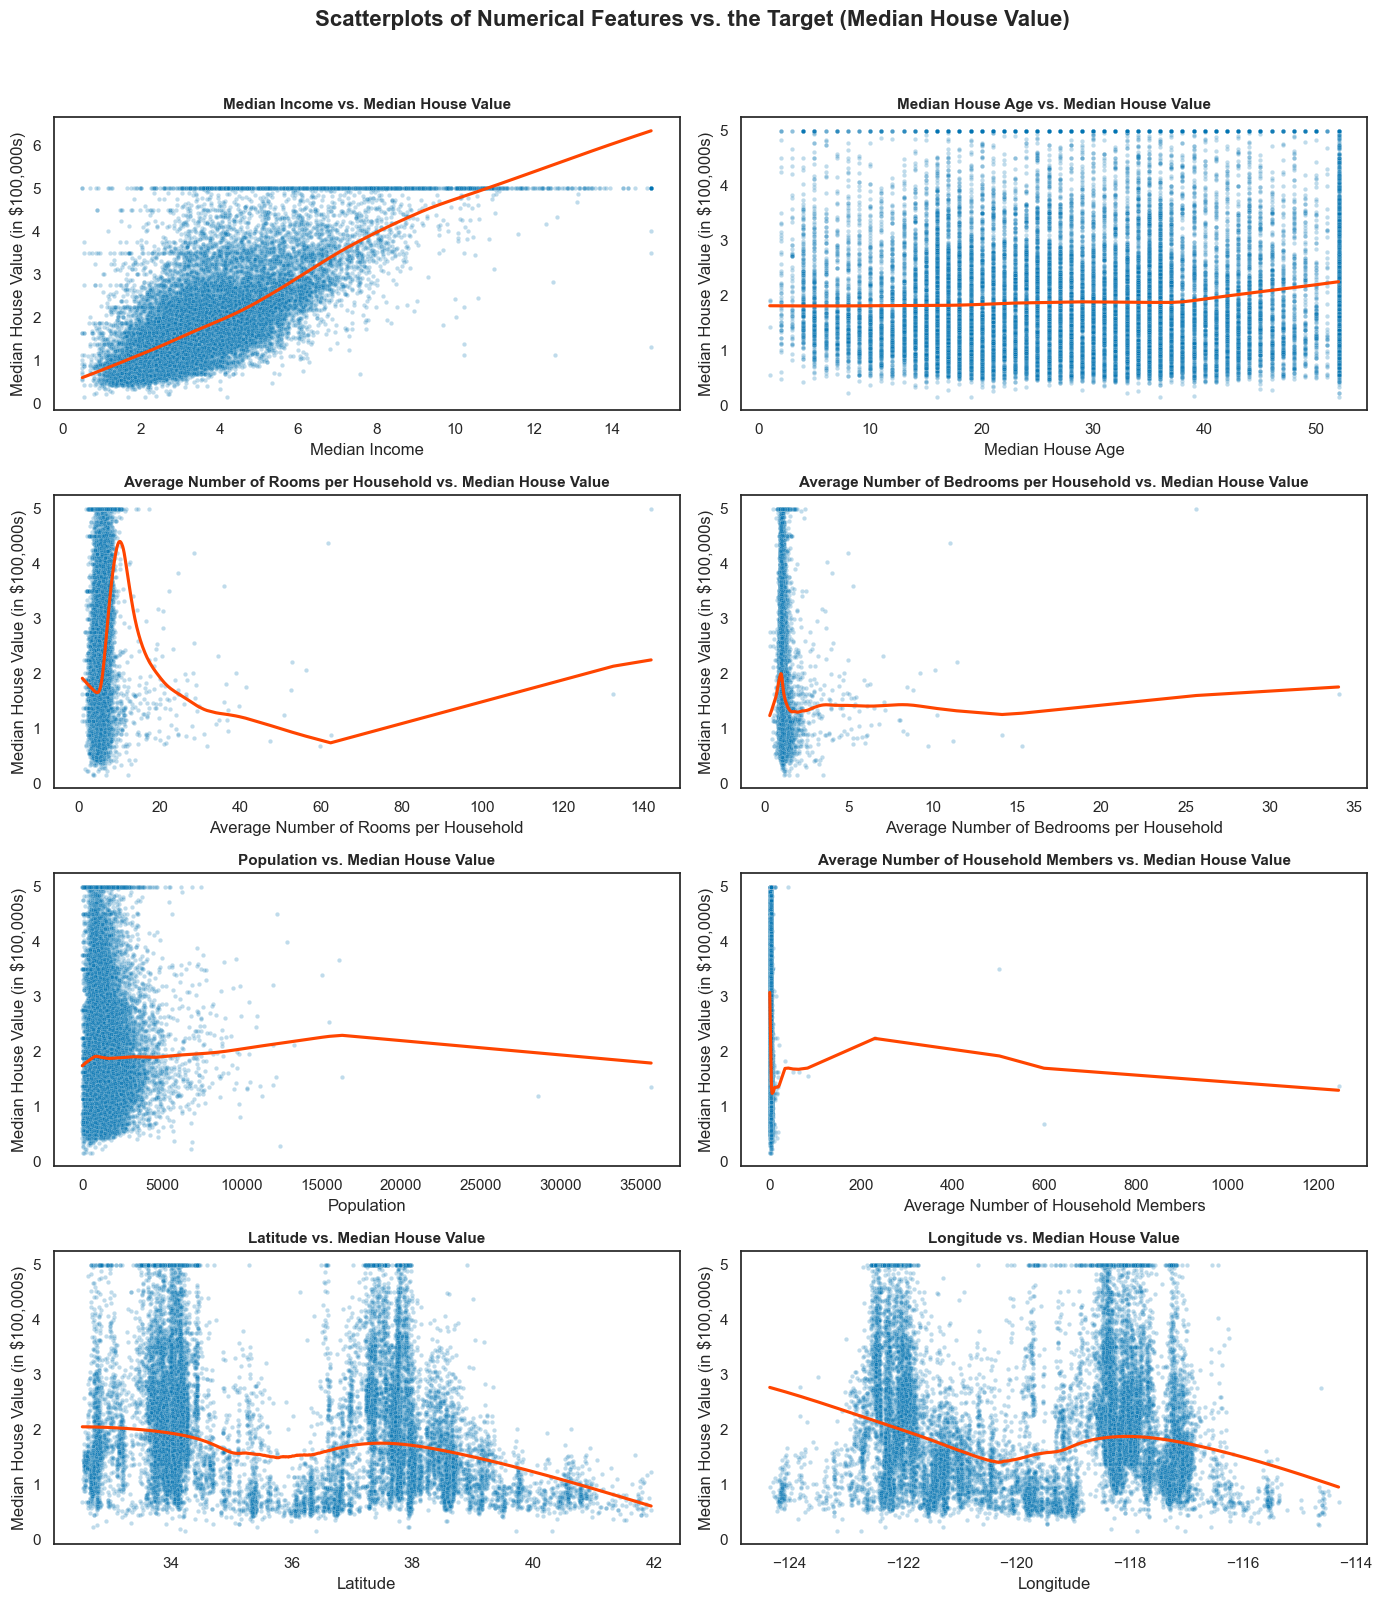

In [41]:
# Scatter plots with smoothing lines
n = len(numeric_features)
ncols = 2
nrows = (n + ncols - 1) // ncols

plt.figure(figsize=(ncols * 7, nrows * 4))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(nrows, ncols, i)
    sns.scatterplot(data=df_eda, x=col, y="med_value", alpha=0.25, s=10)
    sns.regplot(data=df_eda, x=col, y="med_value", scatter=False, lowess=True, color='orangered')
    plt.title(f"{cols_dict[col]} vs. Median House Value", fontweight="bold", fontsize=11)
    plt.xlabel(cols_dict[col])
    plt.ylabel("Median House Value (in $100,000s)")
plt.suptitle(
    "Scatterplots of Numerical Features vs. the Target (Median House Value)",
    fontweight="bold", fontsize=16, y=1)
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

* 📌 **Median Income (`med_income`)**: The scatter plot and LOWESS line indicate a generally linear positive relationship with median house value, but with a pronounced sharp increase in slope around $5,000 median income. This suggests a threshold effect: areas above this income experience much higher house values, and regression trees can effectively exploit this kind of step change for splitting.
* 📌 **Median House Age (`med_age`)**: The relationship with house value is relatively weak and possibly non-monotonic. The LOWESS smoothing line may show minor increases or decreases at certain age ranges, but no clear, dominant threshold. This feature may play a secondary role in tree-based splits.
* 📌 **Average Rooms (`avg_rooms`) & Average Bedrooms (`avg_bedrooms`)**: Both features exhibit a positive association with house value, especially at lower and mid ranges, but the effect flattens for very high values (where extreme outliers appear). Trees may place splits in the midranges to separate typical from atypical blocks.
* 📌 **Population**: The smoothing line is mostly flat, with a possible dip at very high population values. This suggests population has little predictive power for median value in normal ranges, but may help isolate outlier districts (e.g., very densely populated areas).
* 📌 **Average Occupancy (`avg_occup`)**: There is a pronounced drop in house value at high occupancy values, as shown by the downward trend in the LOWESS line. This indicates a threshold effect—tree splits here could separate regions/buildings with unusually high occupancy, likely corresponding to lower-value, multi-family or institutional dwellings.
* 📌 **Latitude (`lat`) & Longitude (`long`)**: Both geographic features display stepwise or clustered relationships with house value, reflecting California’s internal regional price differences. Regression trees can take advantage of these spatial boundaries when forming splits.

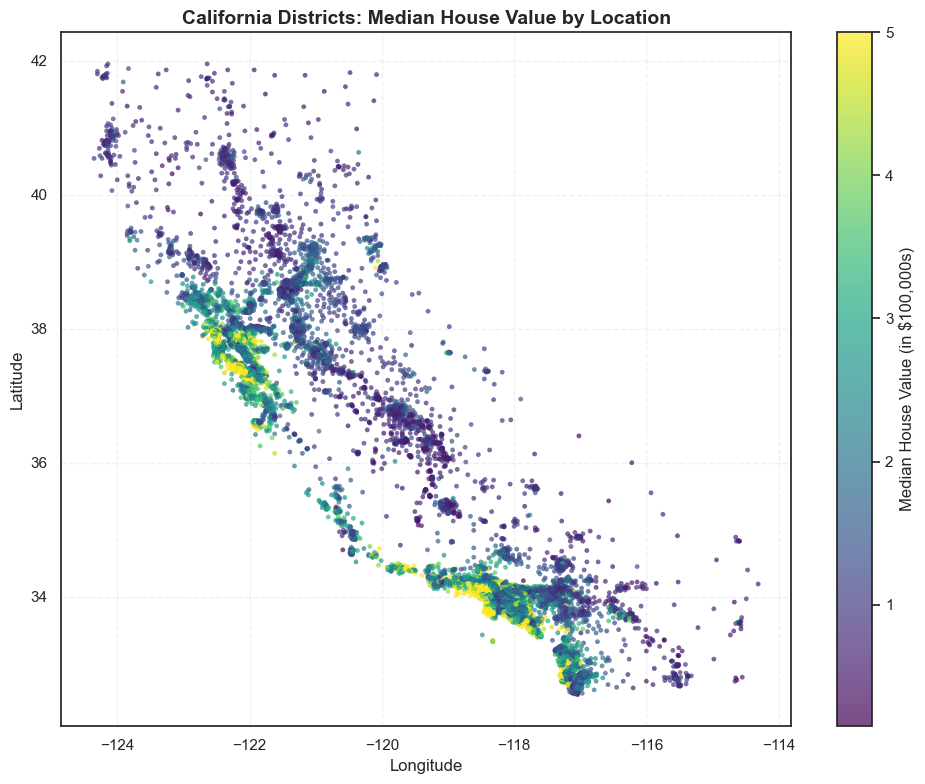

In [42]:
# 2D spatial plot: long vs. lat, colored by med_value.
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    df_eda['long'], df_eda['lat'], 
    c=df_eda['med_value'], cmap='viridis', 
    s=12, alpha=0.7, edgecolor='none'
)
cbar = plt.colorbar(sc)
cbar.set_label('Median House Value (in $100,000s)', fontsize=12)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('California Districts: Median House Value by Location', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

* 📌 The spatial plot of median house value reveals clear geographic clusters. High-value districts are densely concentrated along the California coastline and around major urban centers (such as the San Francisco Bay Area and Los Angeles), while lower-value regions dominate inland and more rural areas. The presence of sharp regional boundaries suggests that geographic features—latitude and longitude—are likely to be highly informative variables, enabling a regression tree to capture these value “steps” through spatially-based splits.

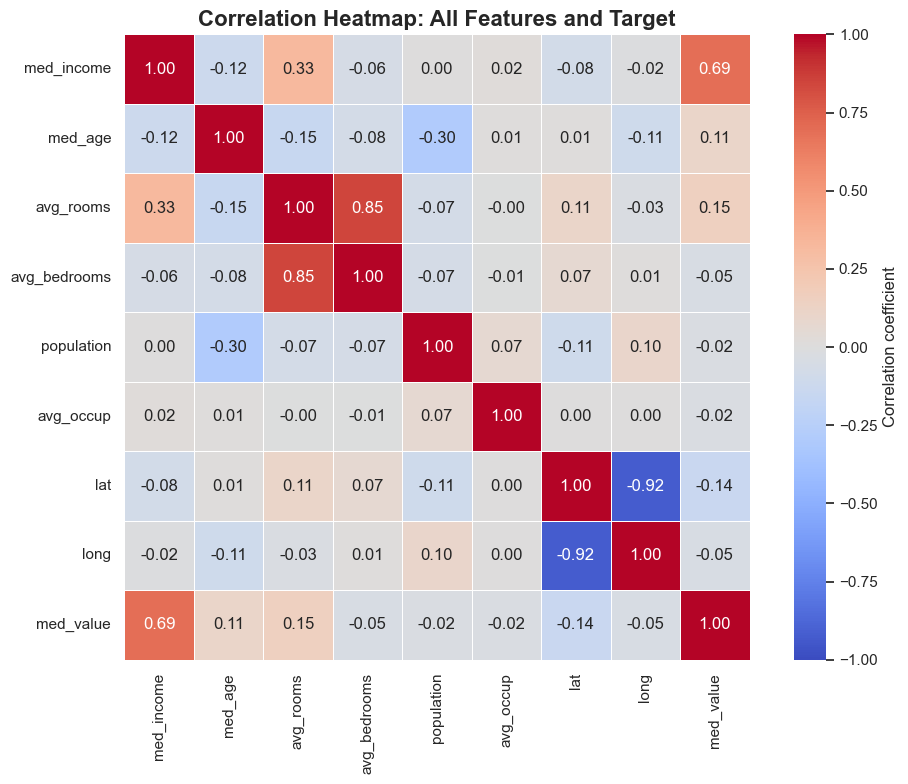

In [43]:
# Correlation Heatmap: All features + target.
plt.figure(figsize=(10, 8))
corr = df_eda.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,             # Annotate with correlation values
    fmt=".2f",              # 2 decimal places for readability
    cmap="coolwarm",        # Blue=negative, Red=positive correlations
    center=0,
    vmax=1.0,
    vmin=-1.0,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation coefficient"}
)
plt.title("Correlation Heatmap: All Features and Target", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

* 📌 The correlation heatmap indicates that `med_income` has the strongest positive linear association with the target (`med_value`), in line with earlier observations. `Latitude` and `longitude` show only weak linear correlations with house value (correlations of approximately -0.14 and -0.05, respectively), but bivariate spatial plots reveal that these features are still highly informative for segmenting regions with sharply different property prices—a structure well-suited to regression tree modeling.

---

> ### 📝 5. Data Understanding Report (Summary)
>
> - **Feature Distributions & Outliers:** Most features—including median income, average rooms, bedrooms, and occupancy—are strongly right-skewed with outliers and heavy tails at high values. The target variable (`med_value`) is also right-skewed, with a visible spike at its upper limit. Regression trees are robust to these issues; no transformations or outlier removal are necessary.
> - **Relationships with the Target:**  
>   - **Median Income (`med_income`)** is the clearest and strongest predictor, with home values increasing sharply above a threshold (~$5,000). This makes it a prime candidate for early tree splits.
>   - **Average Rooms/Bedrooms** show positive association with value, but with flattening at extremes, indicating possible mid-range split points.
>   - **Average Occupancy** features a clear threshold effect: extremely high occupancy is linked to much lower home values.
>   - **Population** shows little direct association except at the highest values, where prices may dip.
>   - **Geography (`lat`, `long`)**: Despite having weak linear correlations with the target, spatial plots reveal striking regional clusters in home values—suggesting regression trees can take advantage of location-based splits. Higher house prices concentrate along the coast and in urban centers.
> - **Feature Redundancy:** Some variables (e.g., average rooms and bedrooms) are highly correlated. However, this is not problematic for regression trees, which naturally select among correlated features.
> - **Summary for Modeling:** The dataset structure and relationships observed strongly support the use of regression trees:
>   - Trees are well-suited for capturing sharp value jumps at thresholds and spatial boundaries.
>   - No pre-processing is needed for outliers, skew, or feature scaling.
>   - The most informative variables for splitting are likely to be median income, average rooms, occupancy, and geographic coordinates.

---

## Stage 6: Data Preparation

### 6.1 Data Cleaning
No data cleaning is required for this dataset. All features are numeric, there are no missing values, and the presence of outliers or skew does not necessitate removal or transformation given the robustness of regression tree models.

### 6.2 Feature Engineering
No additional feature engineering is required. The original attributes are well-suited for regression trees, and no transformation or synthesis of new variables is currently justified by the data or problem context.

### 6.3. Data Structuring and Final Selection
No further data structuring or column selection is required. All original numeric features will be retained for modeling, as they are appropriate for direct use in regression trees. The dataset is already in a tidy format, and no columns need to be dropped or recoded. The next step will use all input features (except the target variable) for training and evaluation.

### 6.4. Final Dataset Split

In [44]:
# Feature matrix and target vector
X = df_eda.drop(columns=['med_value'])
y = df_eda['med_value']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


---

> ### 📝 6. Data Preparation Report (Summary)
> - The data preparation stage required minimal intervention for this project. The California housing dataset is already clean, fully numeric, and free of missing values or formatting issues. All original variables are directly suitable for regression tree modeling—no additional cleaning, feature engineering, or column selection was necessary.
> - The full set of features (excluding the target) was used to construct the feature matrix and target vector, and an 80/20 train-test split was performed (with 80% of the data used for training and 20% reserved for testing). The finalized datasets are now ready for model training and evaluation.

---

## Stage 7: Modeling

### 7.1 Build and Train the Baseline Model

As previously outlined, the baseline modeling approach for this project is a single regression tree using Scikit-learn's `DecisionTreeRegressor`. This choice leverages the method's strength in handling outliers, skewed distributions, and non-linear feature relationships, as discovered during EDA. No alternative candidate models are considered at this stage.


In [45]:
# Build the model
regressor = DecisionTreeRegressor(random_state=42)

# Fit the model to the training data
regressor.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0



---

> ### 📝 7. Modeling Report (Summary)
> - **Model Implemented:** A single Decision Tree Regressor was implemented as the baseline model for this project. This approach was selected due to its robustness to outliers, skewed distributions, and ability to capture non-linear relationships between features and the target variable. No additional candidate or alternative models were considered, in line with the project scope.

---

## Stage 8: Model Evaluation

### 8.1. Evaluate Model on Test Set

In [46]:
# Make predictions on the test set
y_hat = regressor.predict(X_test)

In [47]:
# Get R^2 and adjusted R^2
n_samples, n_features = X_test.shape
r2 = r2_score(y_test, y_hat)
adj_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)

# Get errors
mse = mean_squared_error(y_test, y_hat)
rmse = np.sqrt(mse)

In [48]:
# Print evaluation metrics
print(f"Adjusted R-squared: {adj_r2:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

Adjusted R-squared: 0.62
Root Mean Squared Error: 0.71


* 📌 **Adjusted R-squared:** 0.62. This means that, after accounting for the number of features, the model explains about 62% of the variance in median house values within the test set. This represents a solid baseline for a single regression tree.
* 📌 **Root Mean Squared Error (RMSE):** 0.71. On average, predictions deviate from actual values by about $71,000.

### 8.2. Tree Visualization and Interpretation
To better understand the decision logic of the trained regression tree, we visualize its structure and examine how it splits on different features to make predictions. This aids in identifying the most important variables and the threshold values used for partitioning the data.

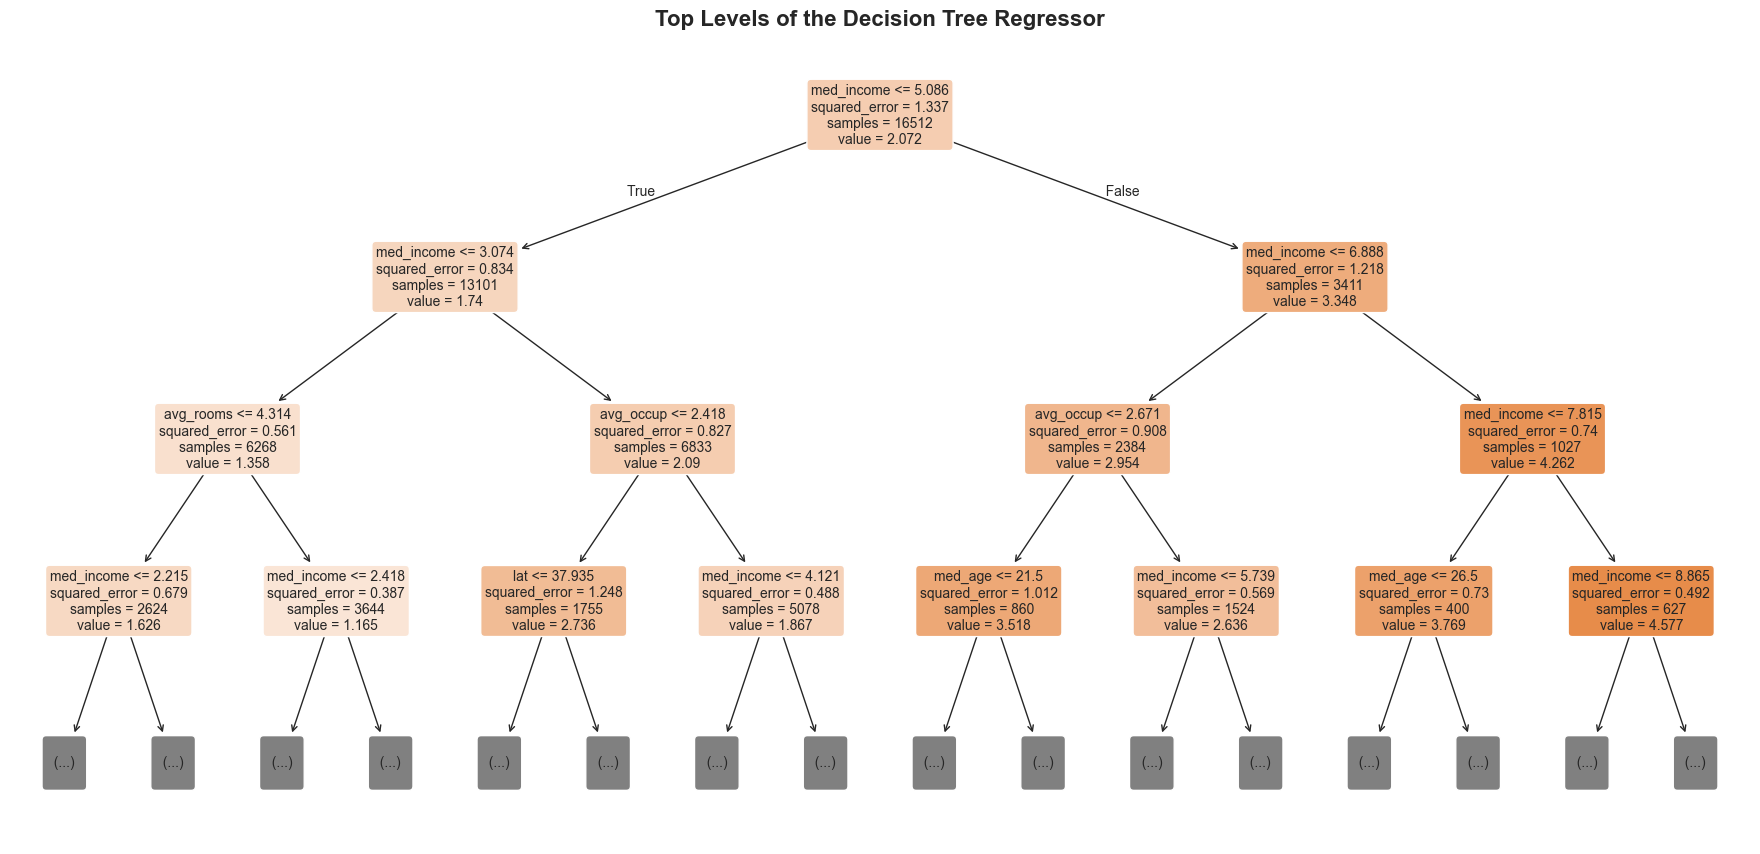

In [49]:
plt.figure(figsize=(20, 10))
plot_tree(
    regressor, 
    feature_names=X.columns, 
    filled=True, 
    rounded=True, 
    max_depth=3,         # show only the top 3 levels for clarity
    fontsize=10
)
plt.title("Top Levels of the Decision Tree Regressor", fontweight="bold", fontsize=16)
plt.show()


---

> ### 📝 8. Model Evaluation Report (Summary)
> - The baseline Decision Tree Regressor achieved an adjusted R-squared of 0.62 and a Root Mean Squared Error (RMSE) of 0.71 on the test set. While these results provide a useful demonstration of the regression tree modeling process, the performance is not sufficient for production deployment.
> - This model will not be deployed, as our goal in this stage was to learn the underlying theory and gain hands-on experience implementing and evaluating regression trees in Python. More advanced modeling techniques and robust evaluation/tuning will be covered in future modules.
>
> ⚠️ **Caution:** While our baseline regression tree provides a solid starting point, further improvements could certainly be achieved—even before introducing systematic cross-validation or grid search. Adjusting key tree hyperparameters such as `max_depth` or `min_samples_leaf` often leads to noticeably better predictive performance. However, per the objectives of this stage, we focused on implementing and understanding the core regression tree algorithm, postponing all forms of manual or automated hyperparameter tuning to later modules.

---

**Next:** [Support Vector Machines Theory](./14_support_vector_machines_theory.md)